# Многоклассовая классификация

## Работа в аудитории

Рассмотрим решение задачи многоклассовой классификации на примере модели турецкого BERT, а именно BERTurk.
Мы должны распознавать семь классов с пользовательским набором данных.
Этот набор данных был составлен из турецких газет и состоит из семи категорий.

In [ ]:
!pip install -q transformers[torch] datasets accelerate -U

In [ ]:
import torch
from torch import cuda
device = 'cuda' if cuda.is_available() else 'cpu'

Скачаем набор данных и подготовим его:

In [ ]:
!wget  https://raw.githubusercontent.com/savasy/TurkishTextClassification/master/TTC4900.csv

--2024-05-05 20:36:26--  https://raw.githubusercontent.com/savasy/TurkishTextClassification/master/TTC4900.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10627541 (10M) [text/plain]
Saving to: ‘TTC4900.csv’

TTC4900.csv         100%[===================>]  10.13M  --.-KB/s    in 0.09s   

2024-05-05 20:36:27 (109 MB/s) - ‘TTC4900.csv’ saved [10627541/10627541]



In [ ]:
import pandas as pd
data= pd.read_csv("TTC4900.csv")
data=data.sample(frac=1.0, random_state=42)
data.head()

,category,text
4657,teknoloji,acıların kedisi sam çatık kaşlı kedi sam in i...
3539,spor,g saray a git santos van_persie den forma ala...
907,dunya,endonezya da çatışmalar 14 ölü endonezya da i...
4353,teknoloji,emniyetten polis logolu virüs uyarısı telefon...
3745,spor,beni türk yapın cristian_baroni yıldırım dan ...


Организуем идентификаторы и метки с помощью id2label и label2id, чтобы модель могла определить, какой идентификатор относится к какой метке. Мы также передадим в модель количество меток NUM_LABELS, чтобы указать размер тонкого слоя классификации поверх модели BERT:

In [ ]:
labels=["teknoloji","ekonomi","saglik","siyaset","kultur","spor","dunya"]
NUM_LABELS= len(labels)
id2label={i:l for i,l in enumerate(labels)}
label2id={l:i for i,l in enumerate(labels)}

In [ ]:
label2id

{'teknoloji': 0,
 'ekonomi': 1,
 'saglik': 2,
 'siyaset': 3,
 'kultur': 4,
 'spor': 5,
 'dunya': 6}

In [ ]:
data["labels"]=data.category.map(lambda x: label2id[x.strip()])

In [ ]:
data.head()

,category,text,labels
4657,teknoloji,acıların kedisi sam çatık kaşlı kedi sam in i...,0
3539,spor,g saray a git santos van_persie den forma ala...,5
907,dunya,endonezya da çatışmalar 14 ölü endonezya da i...,6
4353,teknoloji,emniyetten polis logolu virüs uyarısı telefon...,0
3745,spor,beni türk yapın cristian_baroni yıldırım dan ...,5


Подсчитаем и нанесем на график количество классов, используя объект
pandas:

<Axes: ylabel='count'>

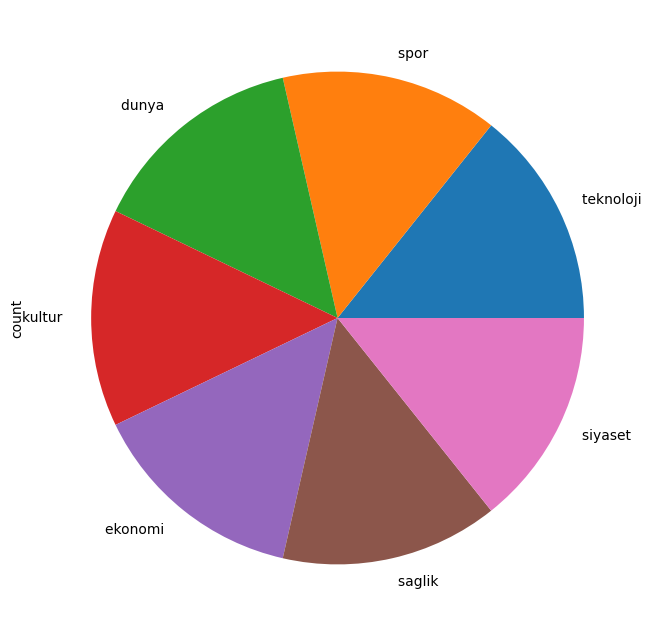

In [ ]:
data.category.value_counts().plot(kind='pie', figsize=(8,8))

Создадим экземпляр модели классификации последовательностей с количеством меток 7, сопоставлениями идентификаторов меток и турецкой моделью BERT (dbmdz/bert-base-turkish-uncased) под названием BERTurk (мы не выбрали DistilBert, поскольку не существует предварительно обученного DistilBert для турецкого языка):

In [ ]:
from transformers import BertTokenizerFast
tokenizer = BertTokenizerFast.from_pretrained("dbmdz/bert-base-turkish-uncased", max_length=512)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/263k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

In [ ]:
from transformers import BertForSequenceClassification
model = BertForSequenceClassification.from_pretrained(
    "dbmdz/bert-base-turkish-uncased", num_labels=NUM_LABELS, id2label=id2label, label2id=label2id
)
model.to(device)
pass

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dbmdz/bert-base-turkish-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Подготовим наборы данных для обучения (50 %), проверки (25 %) и тестирования (25 %) следующим образом:

In [ ]:
SIZE = data.shape[0]

train_texts = list(data.text[:SIZE//2])
val_texts = list(data.text[SIZE//2:(3*SIZE)//4 ])
test_texts = list(data.text[(3*SIZE)//4:])

train_labels = list(data.labels[:SIZE//2])
val_labels = list(data.labels[SIZE//2:(3*SIZE)//4])
test_labels = list(data.labels[(3*SIZE)//4:])

In [ ]:
len(train_texts), len(val_texts), len(test_texts)

(2450, 1225, 1225)

Токенизируем предложения этих наборов данных. В ходе токенизации полученные токены преобразуются  в целые числа (input_ids), которые затем будут передаваться в модель BERT:

In [ ]:
train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings  = tokenizer(val_texts, truncation=True, padding=True)
test_encodings = tokenizer(test_texts, truncation=True, padding=True)

Определим класс для работы с набором данных, в котором реализуем методы `__getitem__` и `__len__, чтобы возвращать элементы и размер набора данных с использованием любого загрузчика данных соответственно:

In [ ]:
from torch.utils.data import Dataset
class CustomDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = CustomDataset(train_encodings, train_labels)
val_dataset = CustomDataset(val_encodings, val_labels)
test_dataset = CustomDataset(test_encodings, test_labels)

Определим ключевые метрики:

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)
    return {
        'Accuracy': acc,
        'F1': f1,
        'Precision': precision,
        'Recall': recall
    }

## Самостоятельная работа

**Задание.** Обучите, которая получит на тестовой части качество по метрике F1 более 0.9.
Проверьте работу модели с использованием pipeline.

In [ ]:
from transformers import TrainingArguments, Trainer

Определим параметры обучения:

In [ ]:
training_args = <ваш код>

Определим объект обучения модели:

In [ ]:
trainer = <ваш код>

Запустим обучение:

In [ ]:
<ваш код>

Сохраним модель

In [ ]:
<ваш код>

('turkish-text-classification-model/tokenizer_config.json',
 'turkish-text-classification-model/special_tokens_map.json',
 'turkish-text-classification-model/vocab.txt',
 'turkish-text-classification-model/added_tokens.json',
 'turkish-text-classification-model/tokenizer.json')

Запустим логический вывод с помощью  pipeline:

In [ ]:
<ваш код>